In [1]:
import pandas as pd
import numpy as np
import os
import cv2

In [2]:
ROOT_FOLDER = 'D:/data/Thyroid radiomics/Stanford cineloop/raw/'
PROCESSED_FOLDER  = 'D:/data/Thyroid radiomics/Stanford cineloop/processed/'
print("listing samples:")
samples = [f for f in os.listdir(ROOT_FOLDER) if os.path.isdir(os.path.join(ROOT_FOLDER, f))]
print(samples)

listing samples:
['100_', '101_', '102_', '103_', '104_', '105_', '106_', '108_', '109_', '10_', '110_', '111_', '112_', '114_', '116_', '117_', '118_', '11_', '120_', '121_', '122_', '123_', '124_', '125_', '126_', '127_', '128_', '129_', '12_', '130_', '132_', '133_', '134_', '136_', '137_', '138_', '139_', '140_', '141_', '142_', '143_', '144_', '145_', '146_', '147_', '148_', '149_', '14_', '150_', '151_', '152_', '153_', '154_', '155_', '157_', '159_', '15_', '160_', '161_', '162_', '163_', '164_', '165_', '166_', '167_', '169_', '16_', '170_', '171_', '172_', '173_', '174_', '175_', '176_', '177_', '178_', '179_', '17_', '180_', '181_', '182_', '183_', '184_', '185_', '186_', '188_', '189_', '18_', '190_', '191_', '192_', '193_', '194_', '195_', '196_', '197_', '198_', '199_', '1_', '200_', '201_', '202_', '203_', '204_', '206_', '207_', '208_', '209_', '20_', '210_', '211_', '212_', '213_', '214_', '21_', '22_', '23_', '24_', '25_', '27_', '28_', '29_', '2_', '30_', '31_', '33_'

In [3]:
sample_id = '99'
masks_folder = ROOT_FOLDER + sample_id + '_/masks/'
images_folder = ROOT_FOLDER + sample_id + '_/frames/'
# get list of frames
frames = []
for filename in os.listdir(images_folder):
    if filename.lower().endswith('.png'):
        name = os.path.splitext(filename)[0].split('_').pop()
        frames.append(name)
print(frames)

['001', '002', '003', '004', '005', '006', '007', '008', '009', '010', '011', '012', '013', '014', '015', '016', '017', '018', '019', '020', '021', '022', '023', '024', '025', '026', '027', '028', '029', '030', '031', '032', '033', '034', '035', '036', '037', '038', '039', '040', '041', '042', '043', '044', '045', '046', '047', '048', '049', '050']


In [ ]:
import cv2
from scipy.ndimage import center_of_mass

# set the base as center of first mask
first_mask_path = masks_folder + sample_id + '_m_' + frames[0] + '.png'
mask = cv2.imread(first_mask_path,cv2.IMREAD_GRAYSCALE)
cY, cX = center_of_mass(mask)
cY = int(cY)
cX = int(cX)
x_lowest, x_highest = [cX,cX]
y_lowest, y_highest = [cY,cY]
ori_y, ori_x = mask.shape

# for each frame, load the mask, get the bounding box and expand to lowest
for frame in frames:
    mask_path = masks_folder + sample_id + '_m_' + frame + '.png'
    mask = cv2.imread(mask_path,cv2.IMREAD_GRAYSCALE)
    indices = np.argwhere(mask)
    y_lower, x_lower = indices.min(axis=0)
    y_upper, x_upper = indices.max(axis=0)
    x_lowest = min(x_lowest, x_lower)
    y_lowest = min(y_lowest, y_lower)
    x_highest = max(x_highest, x_upper)
    y_highest = max(y_highest, y_upper)
print(f"Lower and upper limits in x: ({x_lowest}, {x_highest})")
print(f"Lower and upper limits in y: ({y_lowest}, {y_highest})")

In [ ]:
# make processed folders if they don't exist
processed_sample_folder = PROCESSED_FOLDER + sample_id + '_/'
processed_masks_folder = PROCESSED_FOLDER + sample_id + '_/masks/'
processed_images_folder = PROCESSED_FOLDER + sample_id + '_/frames/'
os.makedirs(processed_sample_folder, exist_ok=True)
os.makedirs(processed_masks_folder, exist_ok=True)
os.makedirs(processed_images_folder, exist_ok=True)

# extract the image and mask for each frame
x_lowest = max(0,x_lowest - 50)
y_lowest = max(0,y_lowest - 50)
x_highest = min(x_highest + 50,ori_x)
y_highest = min(y_highest + 50,ori_y)

In [ ]:
for frame in frames:
    image_path = images_folder + sample_id + '_f_' + frame + '.png'    
    mask_path = masks_folder + sample_id + '_m_' + frame + '.png'
    image = cv2.imread(image_path,cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(mask_path,cv2.IMREAD_GRAYSCALE)
    roi = image[y_lowest:y_highest, x_lowest:x_highest]
    output_image_path = os.path.join(processed_images_folder, f'{sample_id}_f_{frame}.png')
    cv2.imwrite(output_image_path, roi)
    mask_roi = mask[y_lowest:y_highest, x_lowest:x_highest]
    output_mask_path = os.path.join(processed_masks_folder, f'{sample_id}_m_{frame}.png')
    cv2.imwrite(output_mask_path, mask_roi)

In [34]:
import torch
from torchvision import transforms as T
import ttach as tta
import segmentation_models_pytorch as smp

In [35]:
device = torch.device('cuda')

tta_trans = tta.Compose([
            tta.VerticalFlip(),
            tta.HorizontalFlip(),
            tta.Rotate90(angles=[0,180]),
        ])

weight_c2=r'd:/data/tnscui_model/fold1_stage2_trained_on_size_512.pkl'
model_cascade2 = smp.DeepLabV3Plus(encoder_name="efficientnet-b6", encoder_weights=None, in_channels=1, classes=1)
model_cascade2.to(device)
model_cascade2.load_state_dict(torch.load(weight_c2))
model_cascade2 = tta.SegmentationTTAWrapper(model_cascade2, tta_trans,merge_mode='mean')
model_cascade2.eval()


SegmentationTTAWrapper(
  (model): DeepLabV3Plus(
    (encoder): EfficientNetEncoder(
      (_conv_stem): Conv2dStaticSamePadding(
        1, 56, kernel_size=(3, 3), stride=(2, 2), bias=False
        (static_padding): ZeroPad2d((0, 1, 0, 1))
      )
      (_bn0): BatchNorm2d(56, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
      (_blocks): ModuleList(
        (0): MBConvBlock(
          (_depthwise_conv): Conv2dStaticSamePadding(
            56, 56, kernel_size=(3, 3), stride=[1, 1], groups=56, bias=False
            (static_padding): ZeroPad2d((1, 1, 1, 1))
          )
          (_bn1): BatchNorm2d(56, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
          (_se_reduce): Conv2dStaticSamePadding(
            56, 14, kernel_size=(1, 1), stride=(1, 1)
            (static_padding): Identity()
          )
          (_se_expand): Conv2dStaticSamePadding(
            14, 56, kernel_size=(1, 1), stride=(1, 1)
            (

In [ ]:
for frame in frames:
    image_path = images_folder + sample_id + '_f_' + frame + '.png'    
    mask_path = masks_folder + sample_id + '_m_' + frame + '.png'
    image = cv2.imread(image_path,cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(mask_path,cv2.IMREAD_GRAYSCALE)
    roi = image[y_lowest:y_highest, x_lowest:x_highest]
    output_image_path = os.path.join(processed_images_folder, f'{sample_id}_f_{frame}.png')
    cv2.imwrite(output_image_path, roi)
    mask_roi = mask[y_lowest:y_highest, x_lowest:x_highest]
    output_mask_path = os.path.join(processed_masks_folder, f'{sample_id}_m_{frame}.png')
    cv2.imwrite(output_mask_path, mask_roi)
    
    # resize image for stage 2 segmentation
    img = cv2.resize(roi, (512, 512), interpolation=cv2.INTER_CUBIC)
    # process image
    Transform = T.Compose([T.ToTensor()])
    img_tensor = Transform(img)
    img_dtype = img_tensor.dtype
    img_array= (torch.squeeze(img_tensor)).data.cpu().numpy()
    img_tensor = torch.tensor(data = img_array,dtype=img_dtype)
    img = img_tensor
    img = torch.unsqueeze(img, 0)
    img = torch.unsqueeze(img, 0)
    img = img.to(device)
    
    # run the segmentation
    mask_c2 = model_cascade2(img)
    mask_c2 = torch.sigmoid(mask_c2)
    mask_c2_array = (torch.squeeze(mask_c2)).data.cpu().numpy()

    mask_c2_resize = cv2.resize(mask_c2_array, (roi.shape[1],roi.shape[0]), interpolation=cv2.INTER_CUBIC)
    mask_c2_resize = (mask_c2_resize>0.5)
    mask_c2_resize = mask_c2_resize.astype(np.float32)

    mask_c2_array = (mask_c2_array>0.5)
    mask_c2_array = mask_c2_array.astype(np.float32)

    mask_c2_resize = mask_c2_resize * 255
    mask_c2_resize = mask_c2_resize.astype(np.uint8)
    #im= Image.fromarray(mask_c2_resize)
    mask2_path = processed_masks_folder + sample_id + '_m2_' + frame + '.png'
    #im.convert('L').save(mask_path)
    cv2.imwrite(mask2_path, mask_c2_resize)

In [ ]:
print('done')

In [ ]:
### KERNEL FILLING TO REPLACE EMPTY POCKETS ###
frame = '021'
mask_path = processed_masks_folder + sample_id + '_m2_' + frame + '.png'
mask = cv2.imread(mask_path,cv2.IMREAD_GRAYSCALE)
kernel = np.ones((40,40), np.uint8)  # Adjust kernel size as needed
filled_mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
plt.imshow(filled_mask, cmap='gray')

In [ ]:
### CONTOUR FILLING TO REPLACE EMPTY POCKETS ###
frame = '021'
mask_path = processed_masks_folder + sample_id + '_m2_' + frame + '.png'
mask = cv2.imread(mask_path,cv2.IMREAD_GRAYSCALE)

_, binary_mask = cv2.threshold(mask, 1, 255, cv2.THRESH_BINARY)

# Find contours of the zero regions
contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Create a new mask to fill isolated regions
filled_mask = binary_mask.copy()

for contour in contours:
    # Create a mask for each contour
    contour_mask = np.zeros_like(binary_mask)
    cv2.drawContours(contour_mask, [contour], -1, 255, thickness=cv2.FILLED)
    
    # Check if the contour is an isolated region
    if np.count_nonzero(contour_mask) < 500000:  # Adjust the size threshold as needed
        filled_mask[contour_mask == 255] = 255

# Plot the original and filled mask
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title('Original Mask')
plt.imshow(binary_mask, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Filled Mask')
plt.imshow(filled_mask, cmap='gray')
plt.axis('off')

plt.show()


In [ ]:
### all in one using original rather than overall map (images no longer align)
#TODO probably the best one
# If c2 goes out of cut image
# If there is extra original image, then redo cut and run again
ROOT_FOLDER = 'D:/data/Thyroid radiomics/Stanford cineloop/raw/'
PROCESSED_FOLDER  = 'D:/data/Thyroid radiomics/Stanford cineloop/processed2/'

# make processed folders if they don't exist
processed_sample_folder = PROCESSED_FOLDER + sample_id + '_/'
processed_masks_folder = PROCESSED_FOLDER + sample_id + '_/masks/'
processed_images_folder = PROCESSED_FOLDER + sample_id + '_/frames/'
os.makedirs(processed_sample_folder, exist_ok=True)
os.makedirs(processed_masks_folder, exist_ok=True)
os.makedirs(processed_images_folder, exist_ok=True)

# extract the image and mask for each frame
x_lowest = max(0,x_lowest - 50)
y_lowest = max(0,y_lowest - 50)
x_highest = min(x_highest + 50,ori_x)
y_highest = min(y_highest + 50,ori_y)

for frame in frames:
    
    mask_path = masks_folder + sample_id + '_m_' + frame + '.png'
    mask = cv2.imread(mask_path,cv2.IMREAD_GRAYSCALE)
    mask_y, mask_x = mask.shape
    indices = np.argwhere(mask)
    y_lower, x_lower = indices.min(axis=0)
    y_upper, x_upper = indices.max(axis=0)
    x_lower = max(0,x_lower - 50)
    y_lower = max(0,y_lower - 50)
    x_upper = min(x_upper + 50,mask_x)
    y_upper = min(y_upper + 50,mask_y)
    
    image_path = images_folder + sample_id + '_f_' + frame + '.png'    
    image = cv2.imread(image_path,cv2.IMREAD_GRAYSCALE)
    roi = image[y_lower:y_upper, x_lower:x_upper]
    output_image_path = os.path.join(processed_images_folder, f'{sample_id}_f_{frame}.png')
    cv2.imwrite(output_image_path, roi)
    mask_roi = mask[y_lower:y_upper, x_lower:x_upper]
    output_mask_path = os.path.join(processed_masks_folder, f'{sample_id}_m_{frame}.png')
    cv2.imwrite(output_mask_path, mask_roi)
    
    # resize image for stage 2 segmentation
    img = cv2.resize(roi, (512, 512), interpolation=cv2.INTER_CUBIC)
    # process image
    Transform = T.Compose([T.ToTensor()])
    img_tensor = Transform(img)
    img_dtype = img_tensor.dtype
    img_array= (torch.squeeze(img_tensor)).data.cpu().numpy()
    img_tensor = torch.tensor(data = img_array,dtype=img_dtype)
    img = img_tensor
    img = torch.unsqueeze(img, 0)
    img = torch.unsqueeze(img, 0)
    img = img.to(device)
    
    # run the segmentation
    mask_c2 = model_cascade2(img)
    mask_c2 = torch.sigmoid(mask_c2)
    mask_c2_array = (torch.squeeze(mask_c2)).data.cpu().numpy()

    mask_c2_resize = cv2.resize(mask_c2_array, (roi.shape[1],roi.shape[0]), interpolation=cv2.INTER_CUBIC)
    mask_c2_resize = (mask_c2_resize>0.5)
    mask_c2_resize = mask_c2_resize.astype(np.float32)

    mask_c2_array = (mask_c2_array>0.5)
    mask_c2_array = mask_c2_array.astype(np.float32)

    mask_c2_resize = mask_c2_resize * 255
    mask_c2_resize = mask_c2_resize.astype(np.uint8)
    #im= Image.fromarray(mask_c2_resize)
    mask2_path = processed_masks_folder + sample_id + '_m2_' + frame + '.png'
    #im.convert('L').save(mask_path)
    cv2.imwrite(mask2_path, mask_c2_resize)

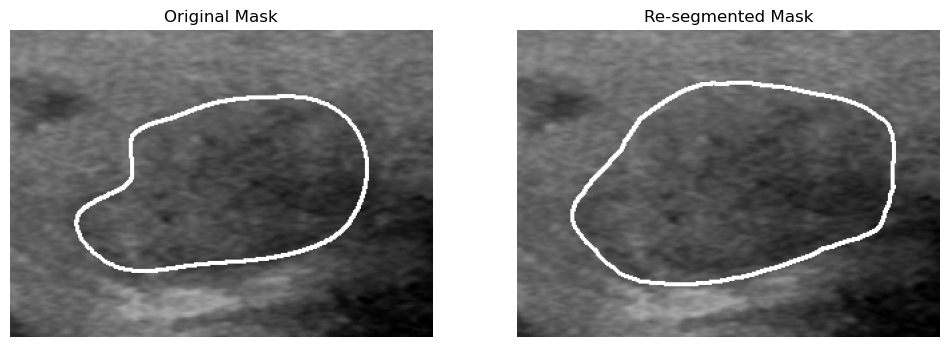

In [12]:
from skimage import measure 
# pick a frame for comparison
frame = '007'
image_path = os.path.join(processed_images_folder, f'{sample_id}_f_{frame}.png')
mask1_path = os.path.join(processed_masks_folder, f'{sample_id}_m_{frame}.png')
mask2_path = processed_masks_folder + sample_id + '_m2_' + frame + '.png'

image = cv2.imread(image_path,cv2.IMREAD_GRAYSCALE)
mask1 = cv2.imread(mask1_path,cv2.IMREAD_GRAYSCALE)
mask2 = cv2.imread(mask2_path,cv2.IMREAD_GRAYSCALE)

image1_np = np.array(image)
image2_np = np.array(image)
mask1_array = np.array(mask1)
mask2_array = np.array(mask2)
contours1 = measure.find_contours(mask1_array, level=0.5)
contours2 = measure.find_contours(mask2_array, level=0.5)
for contour in contours1:
    contour = np.flip(contour, axis=1)  # skimage returns contours in (row, col) format
    contour = contour.astype(np.int32)
    cv2.polylines(image1_np, [contour], isClosed=True, color=(255, 0, 0), thickness=2)  # Draw red contour lines
for contour in contours2:
    contour = np.flip(contour, axis=1)  # skimage returns contours in (row, col) format
    contour = contour.astype(np.int32)
    cv2.polylines(image2_np, [contour], isClosed=True, color=(255, 0, 0), thickness=2)  # Draw red contour lines
    
# Plot the original and filled mask
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title('Original Mask')
plt.imshow(image1_np, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Re-segmented Mask')
plt.imshow(image2_np, cmap='gray')
plt.axis('off')

plt.show()


In [36]:
# model weights
weight_c1=r'd:/data/tnscui_model/fold1_stage1_trained_on_size_256.pkl'
model_cascade1 = smp.DeepLabV3Plus(encoder_name="efficientnet-b6", encoder_weights=None, in_channels=1, classes=1)
model_cascade1.to(device)
model_cascade1.load_state_dict(torch.load(weight_c1))
# model_cascade1 = tta.SegmentationTTAWrapper(model_cascade1, tta_trans,merge_mode='mean')
model_cascade1.eval()

DeepLabV3Plus(
  (encoder): EfficientNetEncoder(
    (_conv_stem): Conv2dStaticSamePadding(
      1, 56, kernel_size=(3, 3), stride=(2, 2), bias=False
      (static_padding): ZeroPad2d((0, 1, 0, 1))
    )
    (_bn0): BatchNorm2d(56, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
    (_blocks): ModuleList(
      (0): MBConvBlock(
        (_depthwise_conv): Conv2dStaticSamePadding(
          56, 56, kernel_size=(3, 3), stride=[1, 1], groups=56, bias=False
          (static_padding): ZeroPad2d((1, 1, 1, 1))
        )
        (_bn1): BatchNorm2d(56, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
        (_se_reduce): Conv2dStaticSamePadding(
          56, 14, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Identity()
        )
        (_se_expand): Conv2dStaticSamePadding(
          14, 56, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Identity()
        )
        (_project_conv): Conv2dStatic

In [39]:
### all in one using step 1 and step 2 segmentation
ROOT_FOLDER = 'D:/data/Thyroid radiomics/Stanford cineloop/raw/'
PROCESSED_FOLDER  = 'D:/data/Thyroid radiomics/Stanford cineloop/processed2/'

# make processed folders if they don't exist
processed_sample_folder = PROCESSED_FOLDER + sample_id + '_/'
processed_masks_folder = PROCESSED_FOLDER + sample_id + '_/masks/'
processed_images_folder = PROCESSED_FOLDER + sample_id + '_/frames/'
os.makedirs(processed_sample_folder, exist_ok=True)
os.makedirs(processed_masks_folder, exist_ok=True)
os.makedirs(processed_images_folder, exist_ok=True)

for frame in frames:
    image_path = images_folder + sample_id + '_f_' + frame + '.png'    
    or_img = cv2.imread(image_path,cv2.IMREAD_GRAYSCALE) # include grayscale conversion
    or_shape = or_img.shape
    img = cv2.resize(or_img, (256, 256), interpolation=cv2.INTER_CUBIC)
    ### STAGE 1 SEGMENTATION ###
    
    # process image
    Transform = T.Compose([T.ToTensor()])
    img_tensor = Transform(img)
    img_dtype = img_tensor.dtype
    img_array= (torch.squeeze(img_tensor)).data.cpu().numpy()
    img_tensor = torch.tensor(data = img_array,dtype=img_dtype)
    img = img_tensor
    img = torch.unsqueeze(img, 0)
    img = torch.unsqueeze(img, 0)
    img = img.to(device)
    
    # run the segmentation
    mask_c1 = model_cascade1(img)
    mask_c1 = torch.sigmoid(mask_c1)
    mask_c1_array = (torch.squeeze(mask_c1)).data.cpu().numpy()
    mask_c1_array = (mask_c1_array>0.5)
    mask_c1_array = mask_c1_array.astype(np.float32)
    #mask_c1_array_biggest = largestConnectComponent(mask_c1_array.astype(int))
    
    mask_y, mask_x = mask_c1_array.shape
    indices = np.argwhere(mask_c1_array)
    y_lower, x_lower = indices.min(axis=0)
    y_upper, x_upper = indices.max(axis=0)
    x_lower = max(0,x_lower - 50)
    y_lower = max(0,y_lower - 50)
    x_upper = min(x_upper + 50,mask_x)
    y_upper = min(y_upper + 50,mask_y)
    dim1_cut_min, dim1_cut_max, dim2_cut_min, dim2_cut_max = y_lower, y_upper, x_lower, x_upper
    
    # map back onto original image
    # Calculate scaling factors
    scale_factor_dim1 = or_shape[0] / 256.0
    scale_factor_dim2 = or_shape[1] / 256.0
    # Map the bounding box dimensions back to the original image
    original_dim1_cut_min = int(dim1_cut_min * scale_factor_dim1)
    original_dim1_cut_max = int(dim1_cut_max * scale_factor_dim1)
    original_dim2_cut_min = int(dim2_cut_min * scale_factor_dim2)
    original_dim2_cut_max = int(dim2_cut_max * scale_factor_dim2)
    # cut out new image
    cut_img = or_img[original_dim1_cut_min:original_dim1_cut_max, original_dim2_cut_min:original_dim2_cut_max]
    # save new image to processed
    processed_path = 'D:/data/Thyroid radiomics/Stanford cineloop/processed3/' + frame + '.PNG'
    cv2.imwrite(processed_path, cut_img)
    # resize new image for stage 2
    img = cv2.resize(cut_img, (512, 512), interpolation=cv2.INTER_CUBIC)
    
    # process image
    Transform = T.Compose([T.ToTensor()])
    img_tensor = Transform(img)
    img_dtype = img_tensor.dtype
    img_array= (torch.squeeze(img_tensor)).data.cpu().numpy()
    img_tensor = torch.tensor(data = img_array,dtype=img_dtype)
    img = img_tensor
    img = torch.unsqueeze(img, 0)
    img = torch.unsqueeze(img, 0)
    img = img.to(device)
    
    # run the segmentation
    mask_c2 = model_cascade2(img)
    mask_c2 = torch.sigmoid(mask_c2)
    mask_c2_array = (torch.squeeze(mask_c2)).data.cpu().numpy()

    mask_c2_resize = cv2.resize(mask_c2_array, (cut_img.shape[1],cut_img.shape[0]), interpolation=cv2.INTER_CUBIC)
    mask_c2_resize = (mask_c2_resize>0.5)
    mask_c2_resize = mask_c2_resize.astype(np.float32)

    mask_c2_array = (mask_c2_array>0.5)
    mask_c2_array = mask_c2_array.astype(np.float32)

    mask_c2_resize = mask_c2_resize * 255
    mask_c2_resize = mask_c2_resize.astype(np.uint8)
    #im= Image.fromarray(mask_c2_resize)
    mask2_path = 'D:/data/Thyroid radiomics/Stanford cineloop/processed3/' + frame + '_mask.png'
    #im.convert('L').save(mask_path)
    cv2.imwrite(mask2_path, mask_c2_resize)

In [10]:
sample_id

'99'

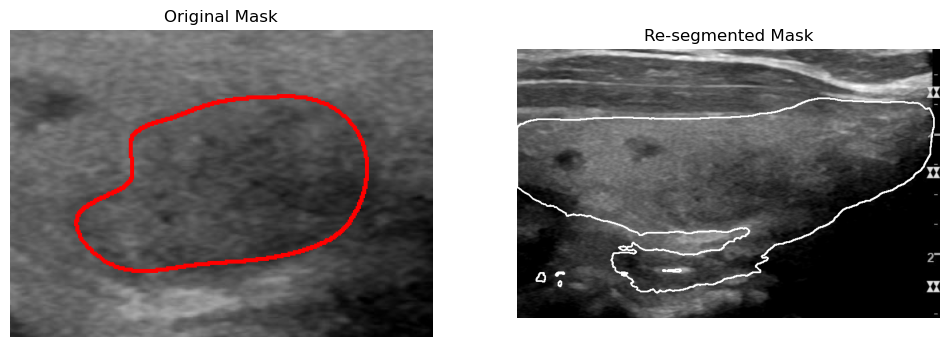

In [6]:
from skimage import measure 
import matplotlib.pyplot as plt

ROOT_FOLDER = 'D:/data/Thyroid radiomics/Stanford cineloop/raw/'
PROCESSED_FOLDER  = 'D:/data/Thyroid radiomics/Stanford cineloop/processed2/'
processed_sample_folder = PROCESSED_FOLDER + sample_id + '_/'
processed_masks_folder = PROCESSED_FOLDER + sample_id + '_/masks/'
processed_images_folder = PROCESSED_FOLDER + sample_id + '_/frames/'

# pick a frame for comparison
frame = '007'
image_path = os.path.join(processed_images_folder, f'{sample_id}_f_{frame}.png')
mask1_path = os.path.join(processed_masks_folder, f'{sample_id}_m_{frame}.png')
image2_path = 'D:/data/Thyroid radiomics/Stanford cineloop/processed3/' + frame + '.png'
mask2_path = 'D:/data/Thyroid radiomics/Stanford cineloop/processed3/' + frame + '_mask.png'

image = cv2.imread(image_path,cv2.IMREAD_GRAYSCALE)
image2 = cv2.imread(image2_path,cv2.IMREAD_GRAYSCALE)
mask1 = cv2.imread(mask1_path,cv2.IMREAD_GRAYSCALE)
mask2 = cv2.imread(mask2_path,cv2.IMREAD_GRAYSCALE)

image1_np = np.array(image)
image2_np = np.array(image2)
mask1_array = np.array(mask1)
mask2_array = np.array(mask2)
contours1 = measure.find_contours(mask1_array, level=0.5)
contours2 = measure.find_contours(mask2_array, level=0.5)
for contour in contours1:
    contour = np.flip(contour, axis=1)  # skimage returns contours in (row, col) format
    contour = contour.astype(np.int32)
    cv2.polylines(image1_np, [contour], isClosed=True, color=(255, 0, 0), thickness=2)  # Draw red contour lines
for contour in contours2:
    contour = np.flip(contour, axis=1)  # skimage returns contours in (row, col) format
    contour = contour.astype(np.int32)
    cv2.polylines(image2_np, [contour], isClosed=True, color=(255, 0, 0), thickness=2)  # Draw red contour lines
    
# Plot the original and filled mask
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title('Original Mask')
plt.imshow(image1_np, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Re-segmented Mask')
plt.imshow(image2_np, cmap='gray')
plt.axis('off')

plt.show()


C:\Users\nbsha\AppData\Local\Temp\ipykernel_25380\2707351121.py:46: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(12, 6))


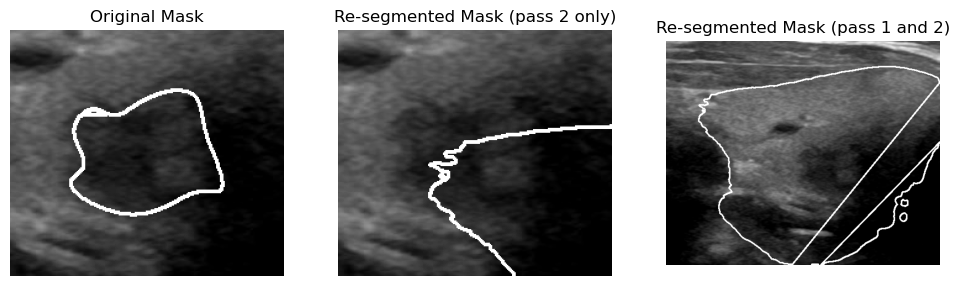

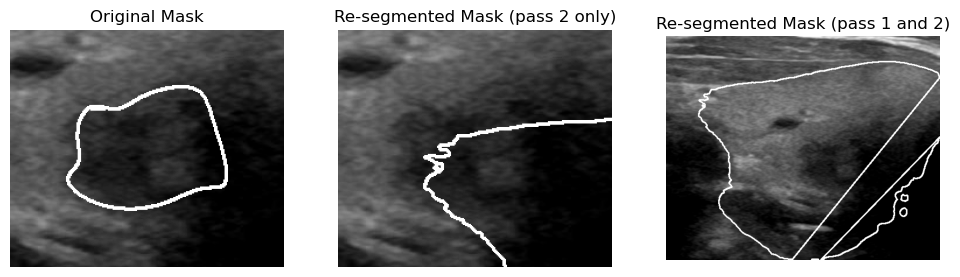

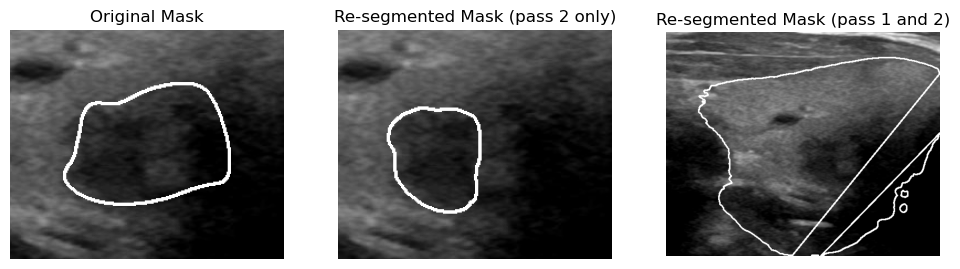

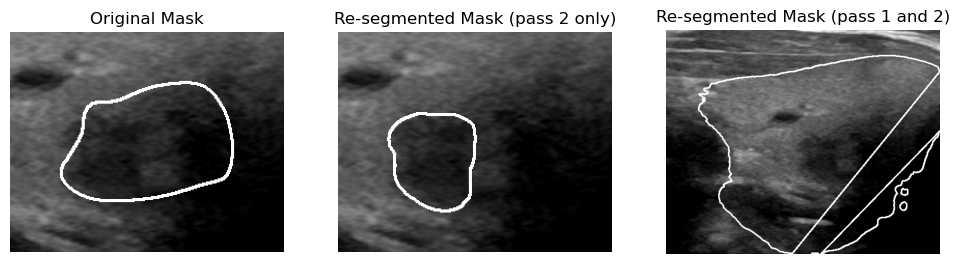

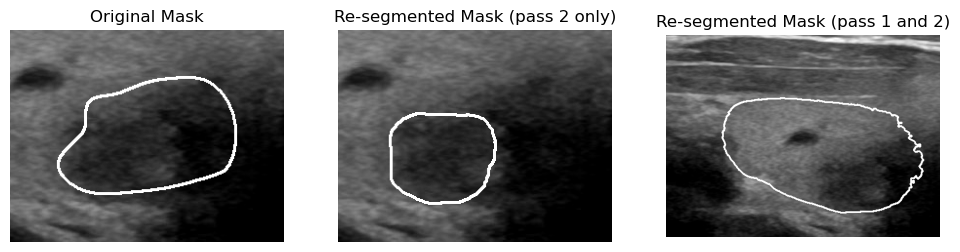

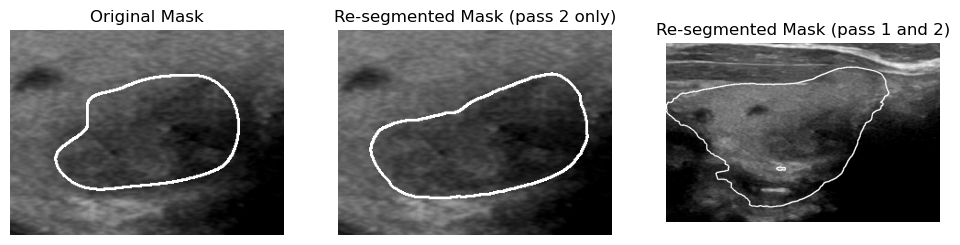

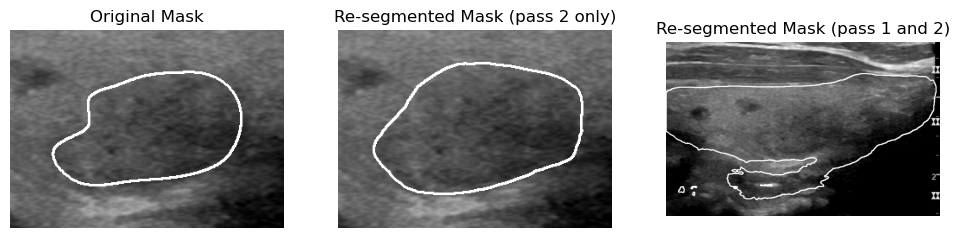

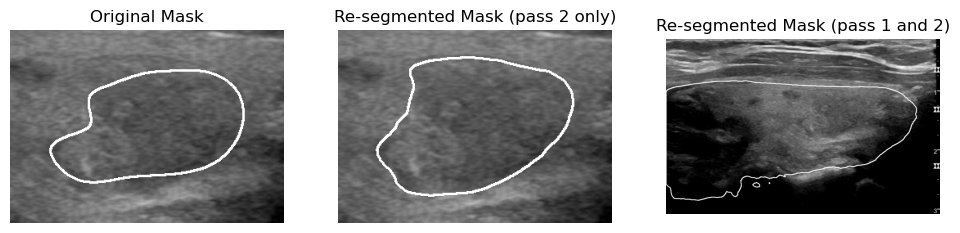

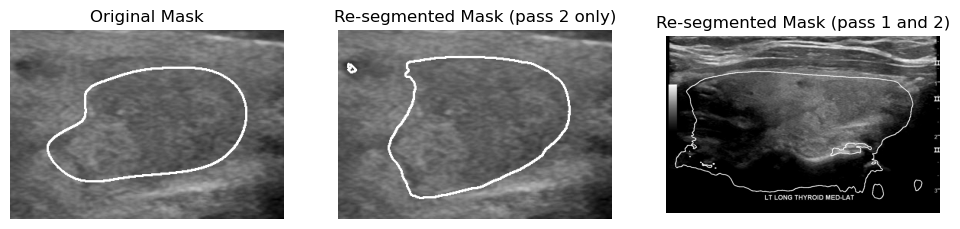

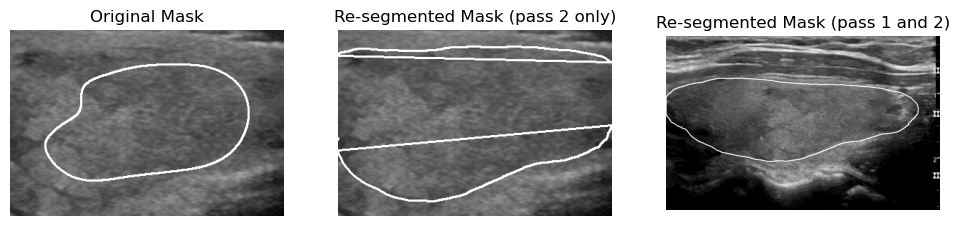

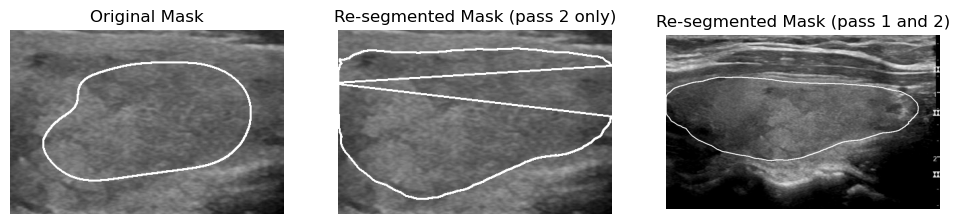

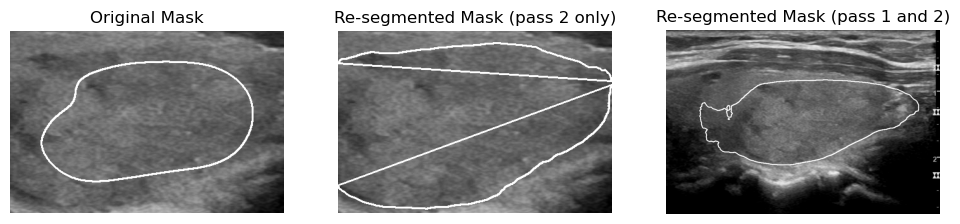

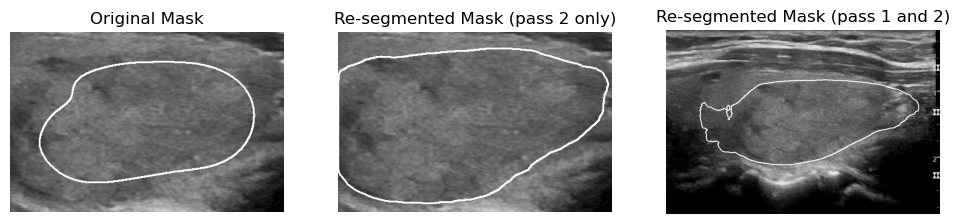

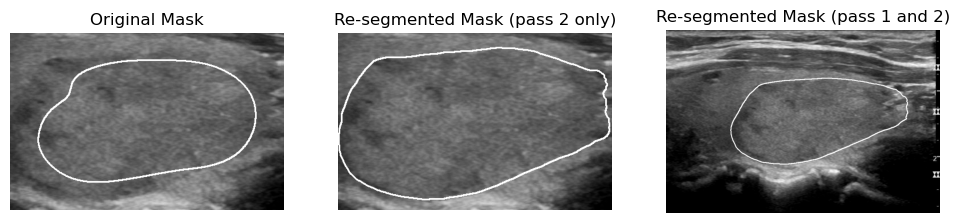

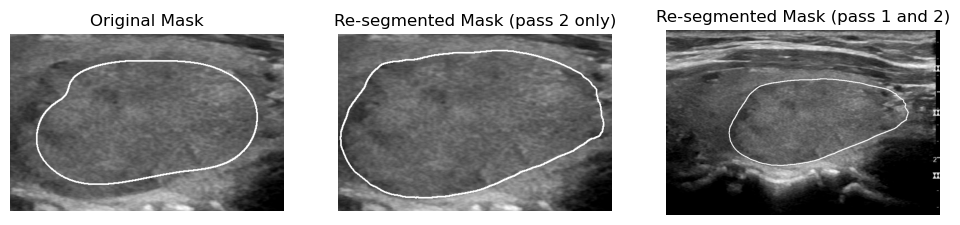

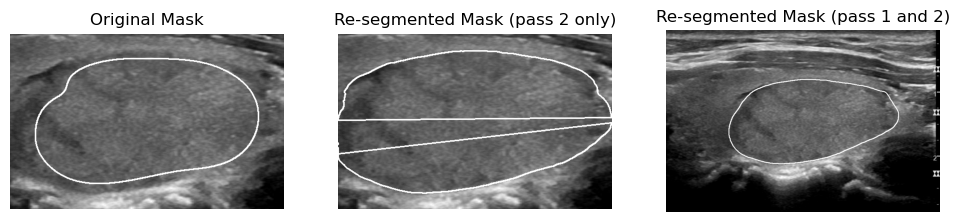

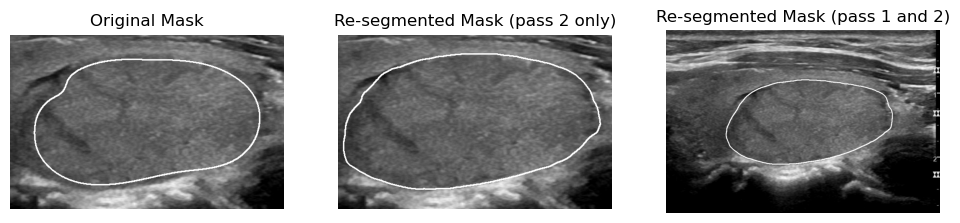

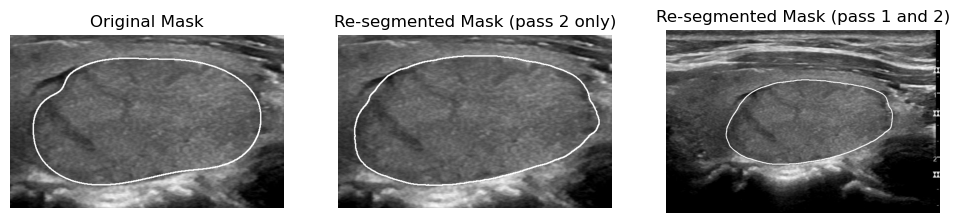

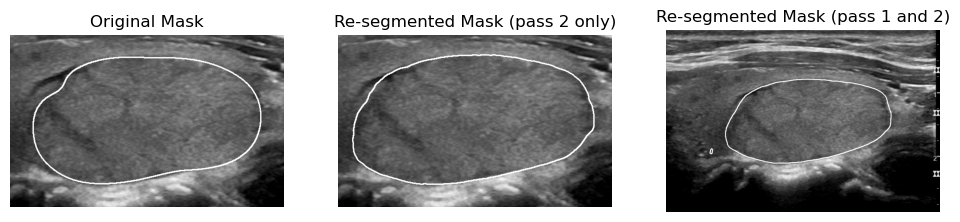

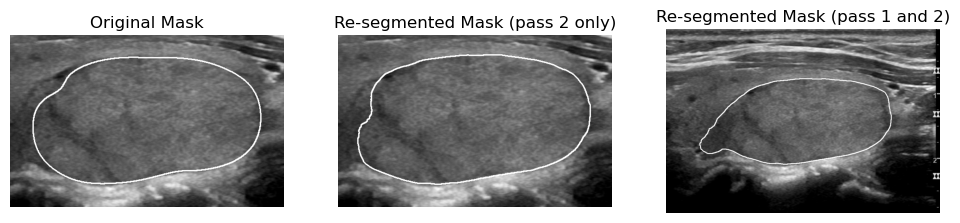

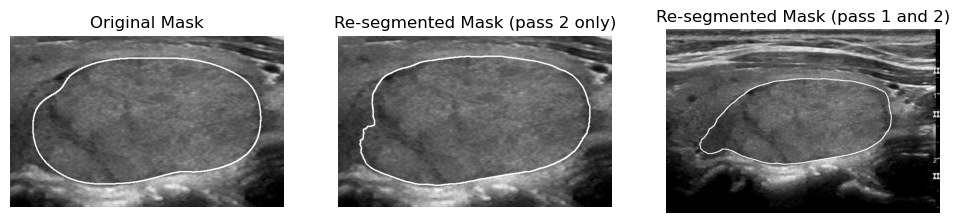

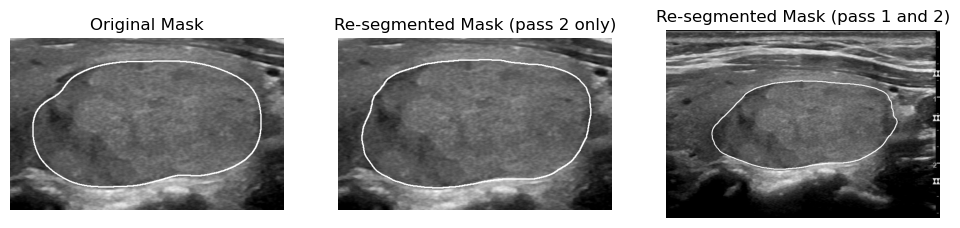

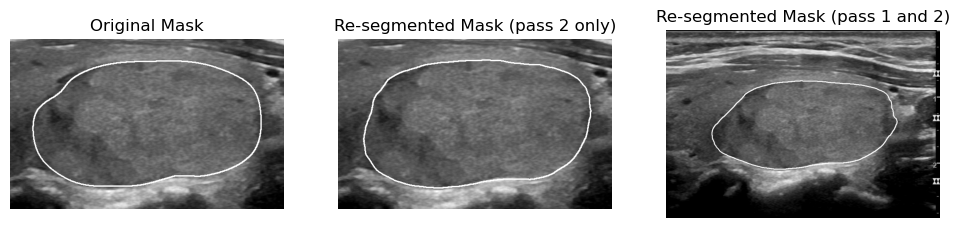

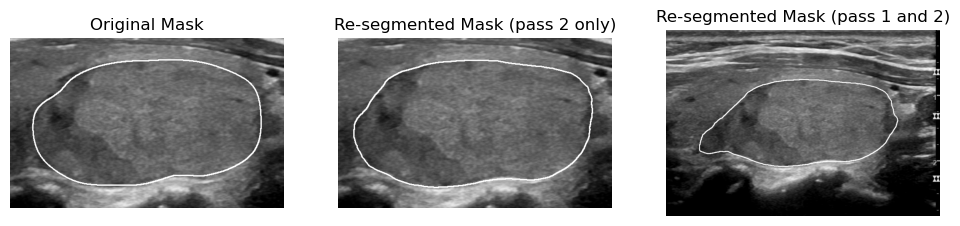

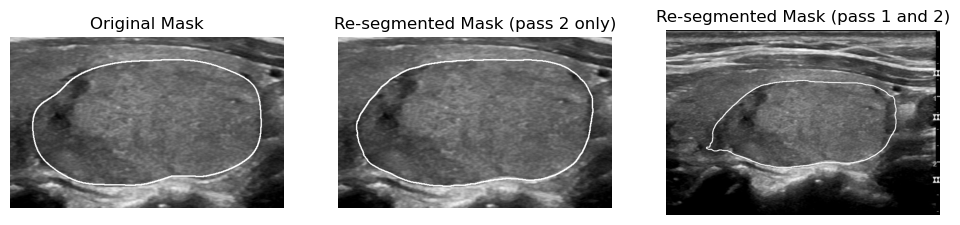

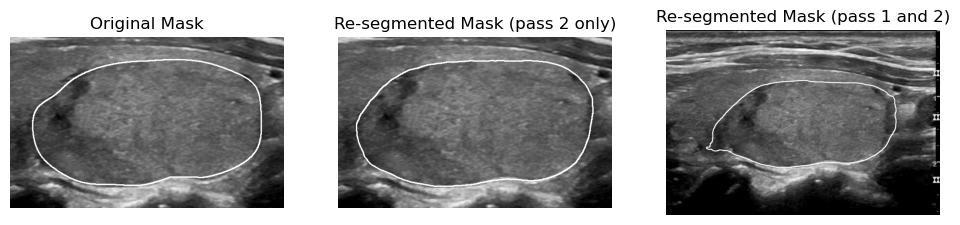

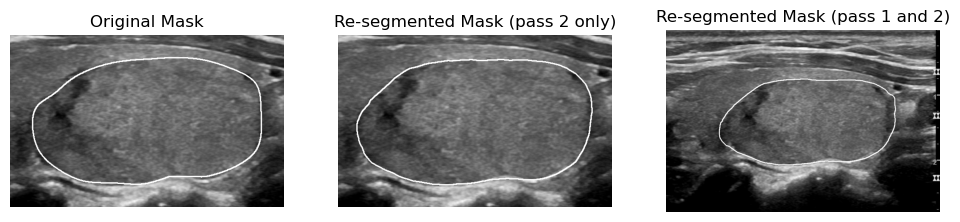

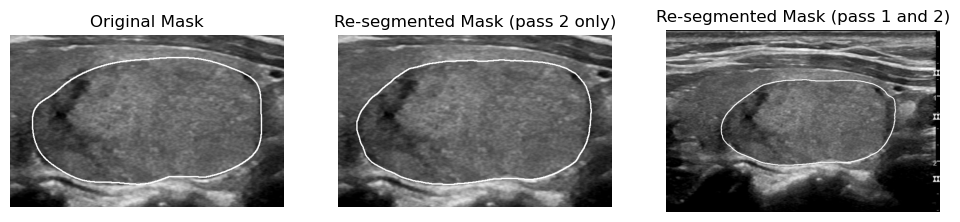

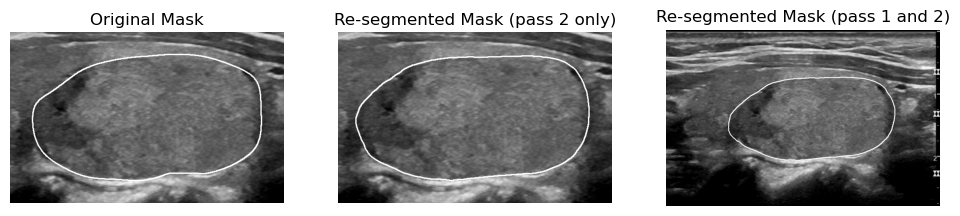

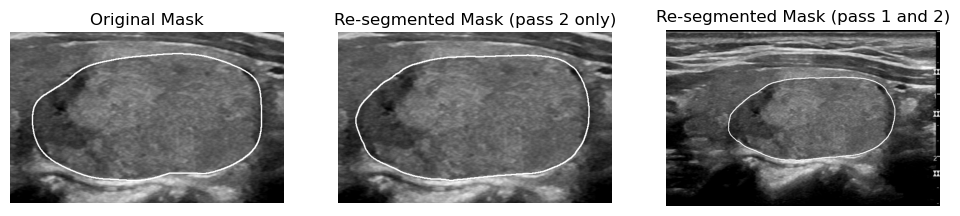

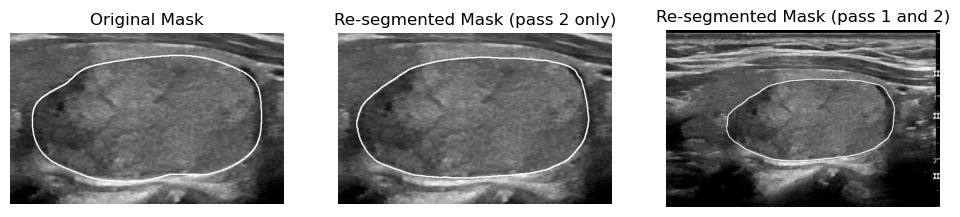

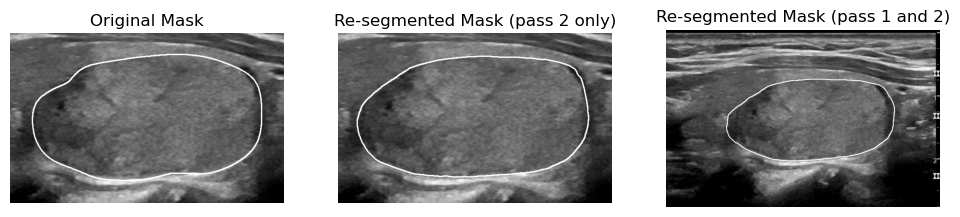

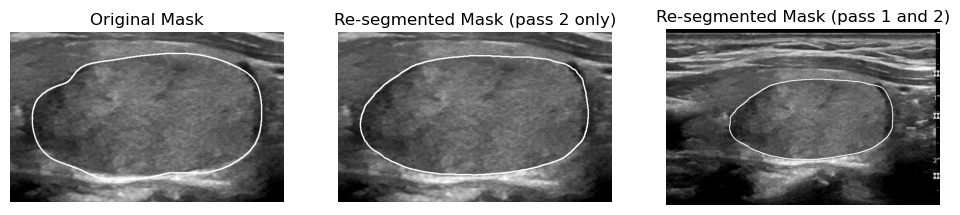

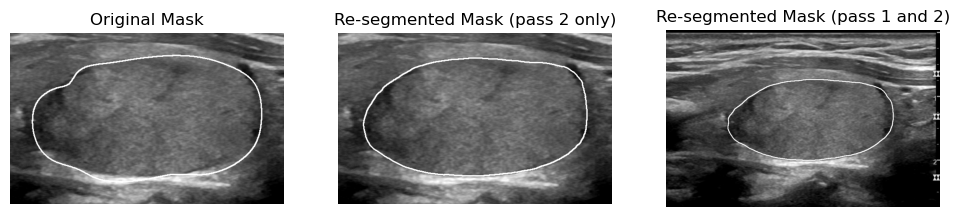

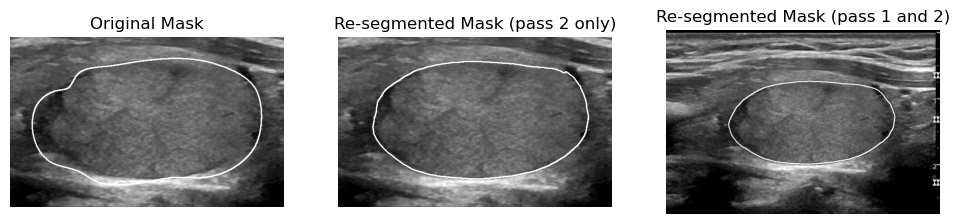

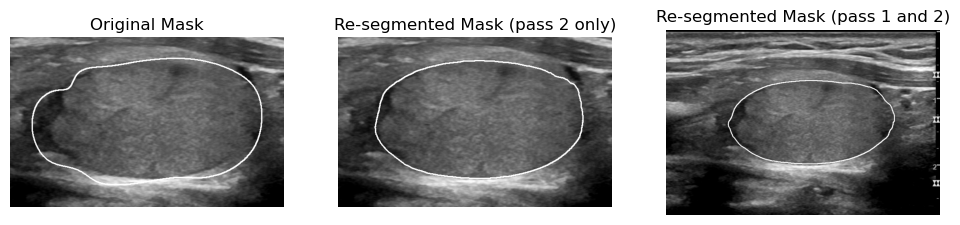

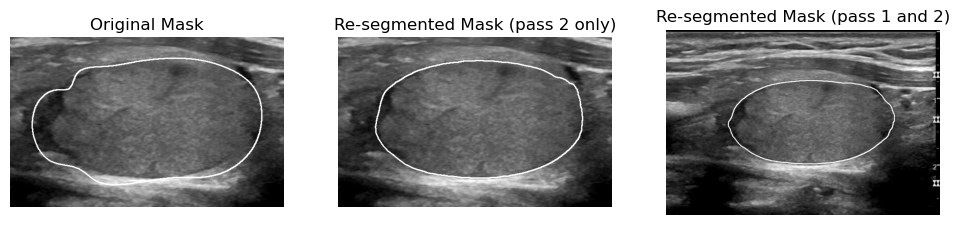

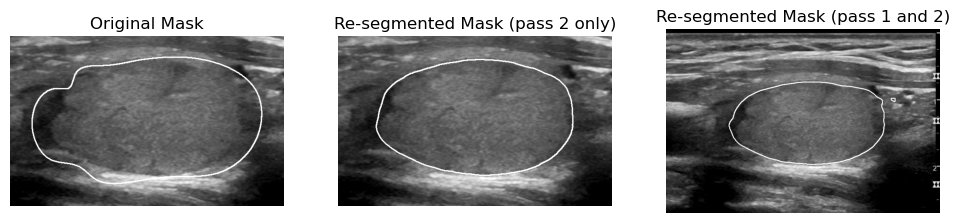

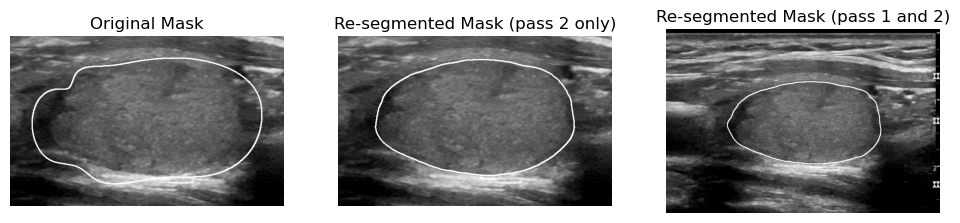

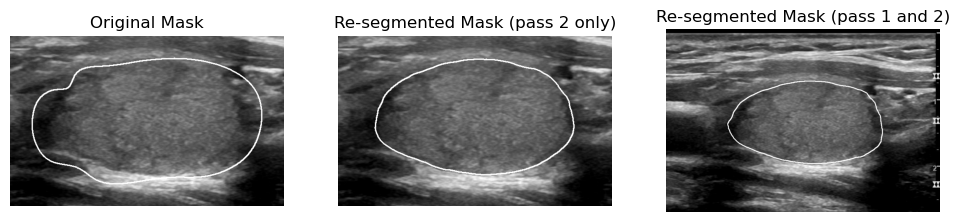

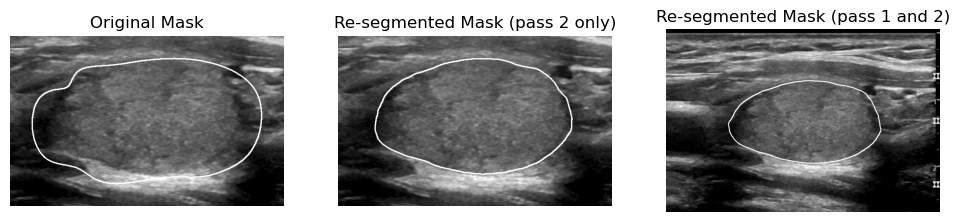

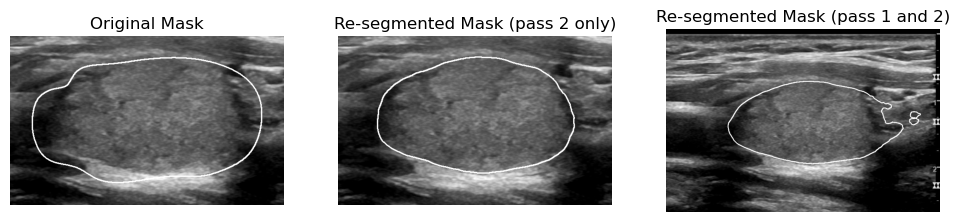

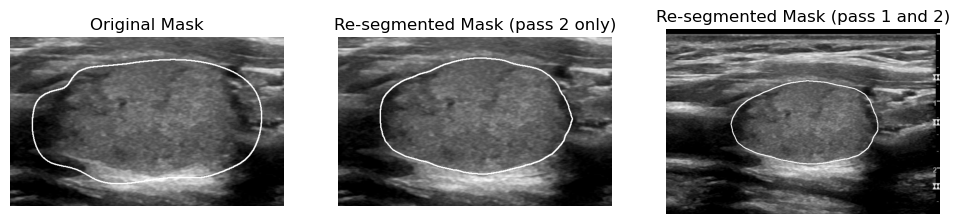

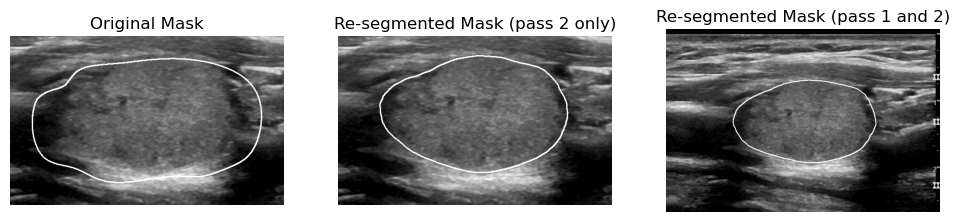

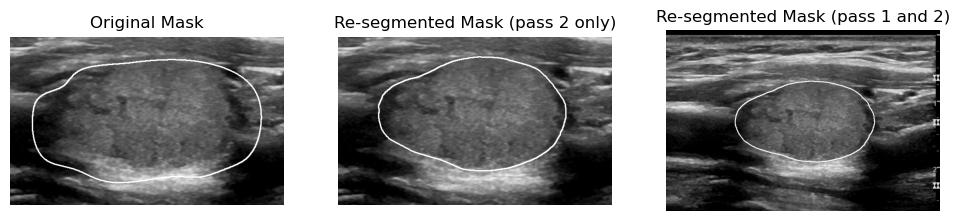

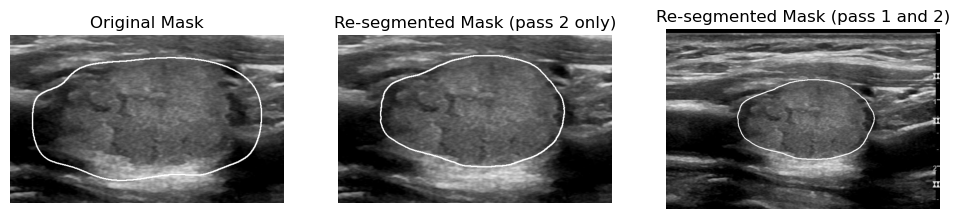

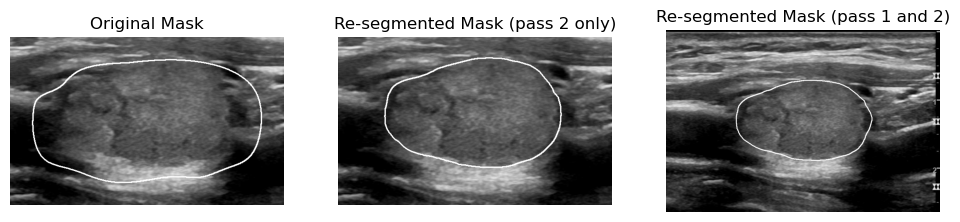

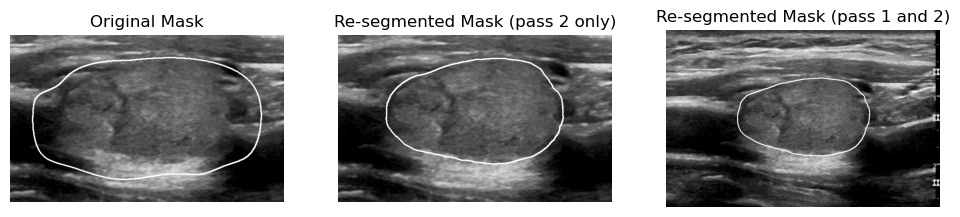

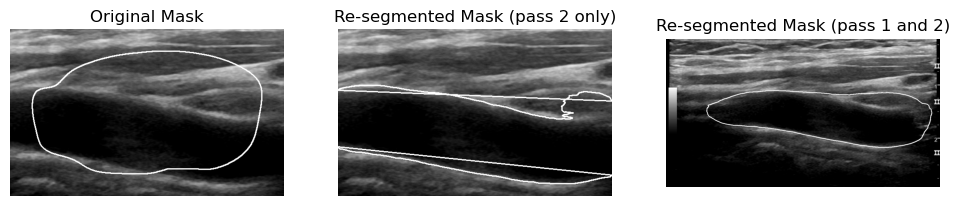

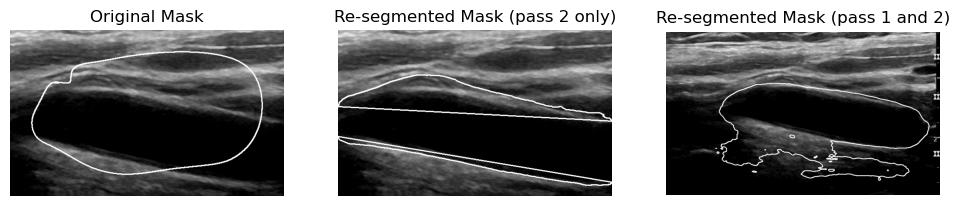

In [41]:
from skimage import measure 
# pick a frame for comparison
# frame = '046'

for frame in frames:
    ROOT_FOLDER = 'D:/data/Thyroid radiomics/Stanford cineloop/raw/'
    PROCESSED_FOLDER  = 'D:/data/Thyroid radiomics/Stanford cineloop/processed2/'
    processed_sample_folder = PROCESSED_FOLDER + sample_id + '_/'
    processed_masks_folder = PROCESSED_FOLDER + sample_id + '_/masks/'
    processed_images_folder = PROCESSED_FOLDER + sample_id + '_/frames/'
    image_path = os.path.join(processed_images_folder, f'{sample_id}_f_{frame}.png')
    mask1_path = os.path.join(processed_masks_folder, f'{sample_id}_m_{frame}.png')
    mask2_path = processed_masks_folder + sample_id + '_m2_' + frame + '.png'
    image3_path = 'D:/data/Thyroid radiomics/Stanford cineloop/processed3/' + frame + '.png'
    mask3_path = 'D:/data/Thyroid radiomics/Stanford cineloop/processed3/' + frame + '_mask.png'

    image = cv2.imread(image_path,cv2.IMREAD_GRAYSCALE)
    mask1 = cv2.imread(mask1_path,cv2.IMREAD_GRAYSCALE)
    mask2 = cv2.imread(mask2_path,cv2.IMREAD_GRAYSCALE)
    image3 = cv2.imread(image3_path,cv2.IMREAD_GRAYSCALE)
    mask3 = cv2.imread(mask3_path,cv2.IMREAD_GRAYSCALE)

    image1_np = np.array(image)
    image2_np = np.array(image)
    image3_np = np.array(image3)
    mask1_array = np.array(mask1)
    mask2_array = np.array(mask2)
    mask3_array = np.array(mask3)
    contours1 = measure.find_contours(mask1_array, level=0.5)
    contours2 = measure.find_contours(mask2_array, level=0.5)
    contours3 = measure.find_contours(mask3_array, level=0.5)
    for contour in contours1:
        contour = np.flip(contour, axis=1)  # skimage returns contours in (row, col) format
        contour = contour.astype(np.int32)
        cv2.polylines(image1_np, [contour], isClosed=True, color=(255, 0, 0), thickness=2)  # Draw red contour lines
    for contour in contours2:
        contour = np.flip(contour, axis=1)  # skimage returns contours in (row, col) format
        contour = contour.astype(np.int32)
        cv2.polylines(image2_np, [contour], isClosed=True, color=(255, 0, 0), thickness=2)  # Draw red contour lines
    for contour in contours3:
        contour = np.flip(contour, axis=1)  # skimage returns contours in (row, col) format
        contour = contour.astype(np.int32)
        cv2.polylines(image3_np, [contour], isClosed=True, color=(255, 0, 0), thickness=2)  # Draw red contour lines

    # Plot the original and filled mask
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 3, 1)
    plt.title('Original Mask')
    plt.imshow(image1_np, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title('Re-segmented Mask (pass 2 only)')
    plt.imshow(image2_np, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.title('Re-segmented Mask (pass 1 and 2)')
    plt.imshow(image3_np, cmap='gray')
    plt.axis('off')

    #plt.show()
    
    output_path = 'D:/data/Thyroid radiomics/Stanford cineloop/temp/' + frame + '.png'
    plt.savefig(output_path)
    plt.close()

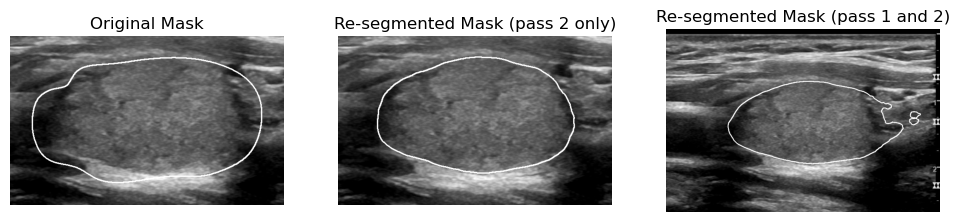

In [47]:
from skimage import measure 

# pick a frame for comparison
frame = '042'

ROOT_FOLDER = 'D:/data/Thyroid radiomics/Stanford cineloop/raw/'
PROCESSED_FOLDER  = 'D:/data/Thyroid radiomics/Stanford cineloop/processed2/'
processed_sample_folder = PROCESSED_FOLDER + sample_id + '_/'
processed_masks_folder = PROCESSED_FOLDER + sample_id + '_/masks/'
processed_images_folder = PROCESSED_FOLDER + sample_id + '_/frames/'
image_path = os.path.join(processed_images_folder, f'{sample_id}_f_{frame}.png')
mask1_path = os.path.join(processed_masks_folder, f'{sample_id}_m_{frame}.png')
mask2_path = processed_masks_folder + sample_id + '_m2_' + frame + '.png'
image3_path = 'D:/data/Thyroid radiomics/Stanford cineloop/processed3/' + frame + '.png'
mask3_path = 'D:/data/Thyroid radiomics/Stanford cineloop/processed3/' + frame + '_mask.png'

image = cv2.imread(image_path,cv2.IMREAD_GRAYSCALE)
mask1 = cv2.imread(mask1_path,cv2.IMREAD_GRAYSCALE)
mask2 = cv2.imread(mask2_path,cv2.IMREAD_GRAYSCALE)
image3 = cv2.imread(image3_path,cv2.IMREAD_GRAYSCALE)
mask3 = cv2.imread(mask3_path,cv2.IMREAD_GRAYSCALE)

image1_np = np.array(image)
image2_np = np.array(image)
image3_np = np.array(image3)
mask1_array = np.array(mask1)
mask2_array = np.array(mask2)
mask3_array = np.array(mask3)
contours1 = measure.find_contours(mask1_array, level=0.5)
contours2 = measure.find_contours(mask2_array, level=0.5)
contours3 = measure.find_contours(mask3_array, level=0.5)
for contour in contours1:
    contour = np.flip(contour, axis=1)  # skimage returns contours in (row, col) format
    contour = contour.astype(np.int32)
    cv2.polylines(image1_np, [contour], isClosed=True, color=(255, 0, 0), thickness=2)  # Draw red contour lines
for contour in contours2:
    contour = np.flip(contour, axis=1)  # skimage returns contours in (row, col) format
    contour = contour.astype(np.int32)
    cv2.polylines(image2_np, [contour], isClosed=True, color=(255, 0, 0), thickness=2)  # Draw red contour lines
for contour in contours3:
    contour = np.flip(contour, axis=1)  # skimage returns contours in (row, col) format
    contour = contour.astype(np.int32)
    cv2.polylines(image3_np, [contour], isClosed=True, color=(255, 0, 0), thickness=2)  # Draw red contour lines
    
# Plot the original and filled mask
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
plt.title('Original Mask')
plt.imshow(image1_np, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('Re-segmented Mask (pass 2 only)')
plt.imshow(image2_np, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('Re-segmented Mask (pass 1 and 2)')
plt.imshow(image3_np, cmap='gray')
plt.axis('off')

plt.show()


In [33]:
mask2_array

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

In [9]:
from radiomics import featureextractor
import SimpleITK as sitk

extractor = featureextractor.RadiomicsFeatureExtractor()
print ("Extraction parameters:\n\t",extractor.settings)
print ("Enabled filters:\n\t",extractor.enabledImagetypes)
print ("Enabled features :\n\t",extractor.enabledFeatures)

# need to limit this else run out of memory
extractor = featureextractor.RadiomicsFeatureExtractor()

# Disable all feature classes, save firstorder
extractor.disableAllFeatures()
extractor.enableFeatureClassByName('firstorder')
# Specify some additional features in the GLCM feature class
# extractor.enableFeaturesByName(glcm=['Autocorrelation', 'Homogeneity1', 'SumSquares'])
#extractor.enableFeaturesByName(glcm=['SumEntropy'])
#extractor.enableFeaturesByName(glszm=['ZoneEntropy'])


Extraction parameters:
	 {'minimumROIDimensions': 2, 'minimumROISize': None, 'normalize': False, 'normalizeScale': 1, 'removeOutliers': None, 'resampledPixelSpacing': None, 'interpolator': 'sitkBSpline', 'preCrop': False, 'padDistance': 5, 'distances': [1], 'force2D': False, 'force2Ddimension': 0, 'resegmentRange': None, 'label': 1, 'additionalInfo': True}
Enabled filters:
	 {'Original': {}}
Enabled features :
	 {'firstorder': [], 'glcm': [], 'gldm': [], 'glrlm': [], 'glszm': [], 'ngtdm': [], 'shape': []}


In [10]:
# temp radiomics for 99_23 + 
from skimage import measure 
import matplotlib.pyplot as plt
#import torch
import torchio as tio
from PIL import Image
import numpy as np

# pick a frame for comparison
frame = '023'
image_path = 'D:/data/Thyroid radiomics/Stanford cineloop/processed3/' + frame + '.png'
mask_path = 'D:/data/Thyroid radiomics/Stanford cineloop/processed3/' + frame + '_mask.png'

subject = tio.Subject(
    image =tio.ScalarImage(image_path),
    mask = tio.LabelMap(mask_path)
)

image = Image.open(image_path).convert('L')  # Convert to grayscale
mask = Image.open(mask_path).convert('L')    # Convert to grayscale
image_np = np.array(image)
mask_np = np.array(mask)
mask_np = (mask_np > 0).astype(np.uint8)  # Convert any non-zero value to 1
tio_image = tio.Image(tensor=image_np[np.newaxis, np.newaxis, :, :], type=tio.INTENSITY)
tio_mask = tio.Image(tensor=mask_np[np.newaxis, np.newaxis, :, :], type=tio.LABEL)
subject = tio.Subject(
    image=tio_image,
    mask=tio_mask
  )

    
# load and run radiomics on pixel level
result = extractor.execute(subject.image.as_sitk(), subject.mask.as_sitk(),voxelBased=True)


In [19]:
feature = 'original_firstorder_Entropy'
# feature = 'original_glszm_ZoneEntropy'
image_array = subject.image['data'][0]
feature_array = sitk.GetArrayFromImage(result[feature])

center_of_mass = np.array(np.where(image_array != 0)).mean(axis=1)
x_center, y_center, z_center = center_of_mass.astype(int).tolist()

axial_cut_image = np.transpose(image_array[:, :, z_center])
axial_cut_feature = feature_array[z_center, :, :]
coronal_cut_image = np.flip(np.transpose(image_array[:, y_center, :].numpy()), axis=0)
coronal_cut_feature = np.flip(feature_array[:, y_center, :], axis = 0)
sagittal_cut_image = np.flip(np.transpose(image_array[x_center, :, :].numpy()), axis=0)
sagittal_cut_feature = np.flip(feature_array[:, :, x_center], axis = 0)


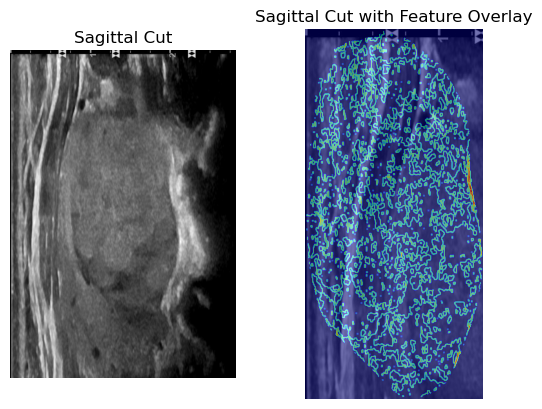

In [20]:
import matplotlib.pyplot as plt
# Display the cuts with feature overlay
# Sagittal Cut
plt.subplot(1, 2, 1)
plt.imshow(sagittal_cut_image, cmap='gray')
plt.title('Sagittal Cut')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(sagittal_cut_image, cmap='gray')
plt.imshow(sagittal_cut_feature, cmap='jet', alpha=0.5)  # Overlay with transparency
plt.title('Sagittal Cut with Feature Overlay')
plt.axis('off')

plt.show()



In [21]:
extractor = featureextractor.RadiomicsFeatureExtractor()
result = extractor.execute(subject.image.as_sitk(), subject.mask.as_sitk())

GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated


In [24]:
import pandas as pd
result

OrderedDict([('diagnostics_Versions_PyRadiomics', 'v3.0.1'),
             ('diagnostics_Versions_Numpy', '1.24.3'),
             ('diagnostics_Versions_SimpleITK', '2.2.1'),
             ('diagnostics_Versions_PyWavelet', '1.4.1'),
             ('diagnostics_Versions_Python', '3.11.5'),
             ('diagnostics_Configuration_Settings',
              {'minimumROIDimensions': 2,
               'minimumROISize': None,
               'normalize': False,
               'normalizeScale': 1,
               'removeOutliers': None,
               'resampledPixelSpacing': None,
               'interpolator': 'sitkBSpline',
               'preCrop': False,
               'padDistance': 5,
               'distances': [1],
               'force2D': False,
               'force2Ddimension': 0,
               'resegmentRange': None,
               'label': 1,
               'additionalInfo': True}),
             ('diagnostics_Configuration_EnabledImageTypes', {'Original': {}}),
             ('diagn